#### Implementing Simple Chatbot using Langgraph

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages ## This adds/appends new messages to the current list and does not overwrite

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

In [4]:
from langchain_groq import ChatGroq
llm_groq=ChatGroq(model="qwen/qwen3.6-27b")
llm_groq.invoke("Hello")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hello". This is a standard greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or task is provided.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly.\n   - Offer assistance.\n   - Keep it open-ended to encourage the user to share what they need.\n4.  **Draft Response (Mental):** "Hello! How can I assist you today?"\n5.  **Refine Response:** Keep it friendly, concise, and professional. Match the tone of the input.\n   - "Hello! How can I help you today?" works well.\n6.  **Final Output Generation:** Output the refined response.✅\n</think>\n\nHello! How can I help you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 186, 'prompt_tokens': 11, 'total_tokens': 197, 'completion_time': 0.374991559, 'completion_tokens_details': None, 'prompt_time': 0.000686436, 'prompt_tokens_detai

#### We will start with creating nodes

In [5]:
def superbot(state: State):
    return {"messages": [llm_groq.invoke(state['messages'])]}

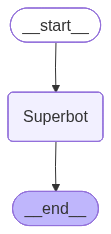

In [6]:
graph = StateGraph(State)

# nodes
graph.add_node("Superbot", superbot)

# edges
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile()

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

graph_builder.invoke({"messages": "Hi, My name is Harshit and I like Cricket"})

{'messages': [HumanMessage(content='Hi, My name is Harshit and I like Cricket', additional_kwargs={}, response_metadata={}, id='3b2e7fcf-7655-4789-bdbf-57acd84d4192'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Harshit\n   - Interest: Cricket\n   - Greeting: "Hi"\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the greeting\n   - Use the name (Harshit)\n   - Acknowledge the interest (Cricket)\n   - Keep it friendly and engaging\n   - Possibly ask a follow-up question to keep the conversation going\n\n3.  **Formulate Response (Mental Draft):**\n   Hi Harshit! Nice to meet you. Cricket\'s an amazing sport—do you follow a particular team or player? Or do you play it yourself? I\'d love to hear more about what you enjoy about it!\n\n4.  **Check Against Guidelines:**\n   - Friendly and personalized? Yes.\n   - Acknowledges both name and interest? Yes.\n   - Open-ended question to encourage conversation? Yes.\n   - 

In [ ]:
### Streaming the responses

graph_builder.stream({"messages": "Hello, My name is Harshit"})

<generator object Pregel.stream at 0x000001F23BF77AB0>

In [11]:
## In this you can see that only the latest message got returned

for event in graph_builder.stream({"messages": "Hello, My name is Harshit"}):
    print(event)

{'Superbot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hello, My name is Harshit"\n   - This is a simple greeting and introduction.\n\n2.  **Identify Key Elements:**\n   - Greeting: "Hello"\n   - Name: "Harshit"\n   - Intent: Introduce themselves, likely expecting a friendly response and possibly further conversation.\n\n3.  **Determine Response Goals:**\n   - Acknowledge the greeting\n   - Use their name\n   - Be friendly and welcoming\n   - Offer assistance\n   - Keep it concise\n\n4.  **Draft Response (Mental):**\n   Hello Harshit! Nice to meet you. How can I assist you today?\n\n5.  **Refine Response:**\n   - Check tone: Friendly, professional\n   - Check accuracy: Uses correct name spelling\n   - Check openness: Invites further conversation\n   - All good.\n\n6.  **Final Output Generation:** (matches the refined draft)\n   "Hello Harshit! Nice to meet you. How can I assist you today?"✅\n</think>\n\nHell

In [12]:
for event in graph_builder.stream({"messages": "Hello, My name is Harshit"}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello, My name is Harshit', additional_kwargs={}, response_metadata={}, id='466e2141-3566-4590-8455-87617c8b43d2')]}
{'messages': [HumanMessage(content='Hello, My name is Harshit', additional_kwargs={}, response_metadata={}, id='466e2141-3566-4590-8455-87617c8b43d2'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hello, My name is Harshit"\n   - This is a simple greeting and introduction.\n\n2.  **Identify Key Elements:**\n   - Greeting: "Hello"\n   - Name: "Harshit"\n   - Intent: Introduce themselves, likely expecting a friendly response and possibly further conversation.\n\n3.  **Determine Response Goals:**\n   - Acknowledge the greeting\n   - Use their name to personalize the response\n   - Be friendly and welcoming\n   - Offer assistance or ask how I can help\n   - Keep it concise\n\n4.  **Draft Response (Mental):**\n   Hello Harshit! Nice to meet you. How can I assist you today?\n\n5. 

In [ ]:
## This one is the same as when only the latest message was returned, so the default stream_mode is 'updates'

for event in graph_builder.stream({"messages": "Hello, My name is Harshit"}, stream_mode="updates"):
    print(event)

{'Superbot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hello, My name is Harshit"\n   - This is a simple greeting and introduction.\n\n2.  **Identify Key Elements:**\n   - Greeting: "Hello"\n   - Name: "Harshit"\n   - Intent: Introduce themselves, likely expecting a friendly response.\n\n3.  **Determine Response Goals:**\n   - Acknowledge the greeting\n   - Use their name to personalize the response\n   - Be friendly and welcoming\n   - Offer assistance\n\n4.  **Draft Response (Mental):**\n   Hello Harshit! Nice to meet you. How can I assist you today?\n\n5.  **Refine Response:**\n   - Keep it warm and professional\n   - Match the tone of the user\n   - Keep it concise\n   - "Hello Harshit! It\'s great to meet you. How can I help you today?"\n\n6.  **Self-Correction/Verification:**\n   - Does it acknowledge the name? Yes.\n   - Is it friendly? Yes.\n   - Does it invite further conversation? Yes.\n   - Any is